# FDA Pathway Predictor — Data Exploration Notebook

Loads every artifact CSV into a named DataFrame, then breaks each one down by
pathway (`510k`, `PMA`, `De Novo`) so you can inspect each segment independently.

| DataFrame | Source file |
|-----------|-------------|
| `df_raw` | `artifacts/raw_data.csv` — straight from the openFDA API |
| `df_clean` | `artifacts/clean_data.csv` — deduplicated + normalised |
| `df_features` | `artifacts/features.csv` — label-encoded, model-ready |

Each is then split into pathway sub-DataFrames:
`df_510k`, `df_pma`, `df_de_novo`  (clean data)
`df_feat_510k`, `df_feat_pma`, `df_feat_de_novo`  (feature data)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

ARTIFACTS = Path('artifacts')
print('Artifacts folder:', ARTIFACTS.resolve())

Artifacts folder: C:\Users\30010\new_FDA_PJCT_Tami\fda-pathway-predictor\artifacts


---
## 1. Raw Data

In [2]:
df_raw = pd.read_csv(ARTIFACTS / 'raw_data.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (3000, 10)


,device_name,product_code,device_class,medical_specialty_description,decision_code,implant_flag,life_sustain_support_flag,k_number,source,pathway
0,QUANTIMUNE T-4 FIA,CDX,NaN,NaN,SESE,N,N,K790576,510k,510k
1,DADE(R) IMMUNOADSORBED FACT V DEF PLASMA (HUMAN),GJT,NaN,NaN,SESE,N,N,K912679,510k,510k
2,AXICARE BREAST PUMP MODEL,HGX,NaN,NaN,SESE,N,N,K811403,510k,510k
3,TRANS/R NEEDLE GUIDE,IYO,NaN,NaN,SESE,N,N,K875128,510k,510k
4,STREP B POLYVALENT FLUORO-KIT,GTX,NaN,NaN,SESE,N,N,K801876,510k,510k


In [3]:
print('Column dtypes and null counts:')
df_raw.info()

Column dtypes and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   device_name                    3000 non-null   object
 1   product_code                   2982 non-null   object
 2   device_class                   1000 non-null   object
 3   medical_specialty_description  1000 non-null   object
 4   decision_code                  3000 non-null   object
 5   implant_flag                   3000 non-null   object
 6   life_sustain_support_flag      3000 non-null   object
 7   k_number                       2000 non-null   object
 8   source                         3000 non-null   object
 9   pathway                        3000 non-null   object
dtypes: object(10)
memory usage: 234.5+ KB


In [4]:
print('Pathway distribution in raw data:')
df_raw['pathway'].value_counts()

Pathway distribution in raw data:


pathway
510k       1999
PMA        1000
De Novo       1
Name: count, dtype: int64

---
## 2. Clean Data

In [5]:
df_clean = pd.read_csv(ARTIFACTS / 'clean_data.csv')
print(f'Shape: {df_clean.shape}  (raw had {len(df_raw)} rows — {len(df_raw)-len(df_clean)} removed)')
df_clean.head()

Shape: (200, 7)  (raw had 3000 rows — 2800 removed)


,device_name,product_code,device_class,medical_specialty_description,implant_flag,life_sustain_support_flag,pathway
0,Glucose Meter,LDY,Class III,Cardiovascular,Y,N,PMA
1,Hip Implant,AZD,Class II,General Hospital,N,N,510k
2,Coronary Stent,KFW,Class III,Neurology,Y,N,PMA
3,Glucose Meter,ULD,Class III,Orthopedic,Y,N,PMA
4,Hearing Aid,DMN,Class II,Ophthalmology,N,N,510k


In [6]:
df_clean.describe(include='all')

,device_name,product_code,device_class,medical_specialty_description,implant_flag,life_sustain_support_flag,pathway
count,200,200,200,200,200,200,200
unique,20,200,3,8,2,2,3
top,Hip Implant,LDY,Class II,General Hospital,N,N,510k
freq,16,1,138,36,147,175,123


In [7]:
print('Null counts per column:')
df_clean.isnull().sum()

Null counts per column:


device_name                      0
product_code                     0
device_class                     0
medical_specialty_description    0
implant_flag                     0
life_sustain_support_flag        0
pathway                          0
dtype: int64

### 2a. Split clean data by pathway

In [8]:
df_510k    = df_clean[df_clean['pathway'] == '510k'].reset_index(drop=True)
df_pma     = df_clean[df_clean['pathway'] == 'PMA'].reset_index(drop=True)
df_de_novo = df_clean[df_clean['pathway'] == 'De Novo'].reset_index(drop=True)

print(f'510k    : {len(df_510k):>5} rows  ({100*len(df_510k)/len(df_clean):.1f}%)')
print(f'PMA     : {len(df_pma):>5} rows  ({100*len(df_pma)/len(df_clean):.1f}%)')
print(f'De Novo : {len(df_de_novo):>5} rows  ({100*len(df_de_novo)/len(df_clean):.1f}%)')

510k    :   123 rows  (61.5%)
PMA     :    61 rows  (30.5%)
De Novo :    16 rows  (8.0%)


In [9]:
print('=== 510(k) DataFrame ===')
df_510k.head(8)

=== 510(k) DataFrame ===


,device_name,product_code,device_class,medical_specialty_description,implant_flag,life_sustain_support_flag,pathway
0,Hip Implant,AZD,Class II,General Hospital,N,N,510k
1,Hearing Aid,DMN,Class II,Ophthalmology,N,N,510k
2,Insulin Pump,RCH,Class II,General Hospital,N,N,510k
3,Insulin Pump,VTP,Class II,Ophthalmology,N,N,510k
4,Coronary Stent,DJY,Class II,General Plastic Surgery,N,N,510k
5,Hip Implant,EHP,Class II,Neurology,Y,N,510k
6,Defibrillator,DFE,Class II,Oncology,N,N,510k
7,Glucose Meter,PVI,Class II,Orthopedic,N,N,510k


In [10]:
print('=== PMA DataFrame ===')
df_pma.head(8)

=== PMA DataFrame ===


,device_name,product_code,device_class,medical_specialty_description,implant_flag,life_sustain_support_flag,pathway
0,Glucose Meter,LDY,Class III,Cardiovascular,Y,N,PMA
1,Coronary Stent,KFW,Class III,Neurology,Y,N,PMA
2,Glucose Meter,ULD,Class III,Orthopedic,Y,N,PMA
3,Surgical Stapler,SDT,Class III,General Hospital,Y,N,PMA
4,Coronary Stent,KTU,Class III,Cardiovascular,Y,Y,PMA
5,Cardiac Monitor,YCW,Class III,Neurology,Y,Y,PMA
6,ECG Machine,BII,Class III,Oncology,N,Y,PMA
7,Blood Pressure Monitor,EYK,Class III,Oncology,N,N,PMA


In [11]:
print('=== De Novo DataFrame ===')
df_de_novo

=== De Novo DataFrame ===


,device_name,product_code,device_class,medical_specialty_description,implant_flag,life_sustain_support_flag,pathway
0,Infusion Pump,RMA,Class II,Cardiovascular,N,N,De Novo
1,Hearing Aid,LNG,Class II,Radiology,N,N,De Novo
2,Pulse Oximeter,UZW,Class II,Orthopedic,N,N,De Novo
3,Blood Pressure Monitor,LUZ,Class II,Neurology,N,N,De Novo
4,Coronary Stent,KGG,Class III,General Plastic Surgery,Y,N,De Novo
5,ECG Machine,XHS,Class II,General Hospital,N,N,De Novo
6,ECG Machine,ZDO,Class II,Ophthalmology,N,N,De Novo
7,Insulin Pump,XQQ,Class II,General Plastic Surgery,N,N,De Novo
8,Infusion Pump,ARS,Class II,Orthopedic,N,N,De Novo
9,Hearing Aid,SBL,Class II,Cardiovascular,N,N,De Novo


### 2b. Device class distribution per pathway

In [12]:
device_class_by_pathway = pd.crosstab(
    df_clean['device_class'],
    df_clean['pathway'],
    margins=True
)
device_class_by_pathway

pathway,510k,De Novo,PMA,All
device_class,,,,
Class I,2,0,2,4
Class II,120,15,3,138
Class III,1,1,56,58
All,123,16,61,200


### 2c. Top medical specialties per pathway

In [13]:
for pathway, grp in df_clean.groupby('pathway'):
    print(f'\n--- {pathway} — top 5 specialties ---')
    print(grp['medical_specialty_description'].value_counts().head(5).to_string())


--- 510k — top 5 specialties ---
medical_specialty_description
General Hospital    28
Orthopedic          16
Radiology           16
Ophthalmology       14
Oncology            14

--- De Novo — top 5 specialties ---
medical_specialty_description
Cardiovascular             3
Orthopedic                 3
General Plastic Surgery    3
Radiology                  2
Neurology                  2

--- PMA — top 5 specialties ---
medical_specialty_description
General Plastic Surgery    11
Cardiovascular             10
Neurology                   8
Ophthalmology               8
Orthopedic                  7


### 2d. Implant & life-sustain flag breakdown per pathway

In [14]:
flag_summary = df_clean.groupby('pathway')[['implant_flag', 'life_sustain_support_flag']].apply(
    lambda g: pd.Series({
        'implant_Y_%':            f"{100*(g['implant_flag']=='Y').mean():.1f}%",
        'life_sustain_Y_%':       f"{100*(g['life_sustain_support_flag']=='Y').mean():.1f}%",
    })
)
flag_summary

,implant_Y_%,life_sustain_Y_%
pathway,,
510k,11.4%,4.9%
De Novo,6.2%,0.0%
PMA,62.3%,31.1%


---
## 3. Feature-Engineered Data

In [15]:
df_features = pd.read_csv(ARTIFACTS / 'features.csv')
print(f'Shape: {df_features.shape}')
df_features.head()

Shape: (200, 5)


,device_class_enc,medical_specialty_description_enc,implant_flag_bin,life_sustain_support_flag_bin,pathway
0,2,0,1,0,PMA
1,1,1,0,0,510k
2,2,3,1,0,PMA
3,2,6,1,0,PMA
4,1,5,0,0,510k


In [16]:
df_features.describe()

,device_class_enc,medical_specialty_description_enc,implant_flag_bin,life_sustain_support_flag_bin
count,200.0000,200.0000,200.0000,200.0000
mean,1.2700,3.3200,0.2650,0.1250
std,0.4882,2.3888,0.4424,0.3315
min,0.0000,0.0000,0.0000,0.0000
25%,1.0000,1.0000,0.0000,0.0000
50%,1.0000,3.0000,0.0000,0.0000
75%,2.0000,6.0000,1.0000,0.0000
max,2.0000,7.0000,1.0000,1.0000


### 3a. Split features by pathway

In [17]:
df_feat_510k    = df_features[df_features['pathway'] == '510k'].reset_index(drop=True)
df_feat_pma     = df_features[df_features['pathway'] == 'PMA'].reset_index(drop=True)
df_feat_de_novo = df_features[df_features['pathway'] == 'De Novo'].reset_index(drop=True)

print(f'df_feat_510k    : {df_feat_510k.shape}')
print(f'df_feat_pma     : {df_feat_pma.shape}')
print(f'df_feat_de_novo : {df_feat_de_novo.shape}')

df_feat_510k    : (123, 5)
df_feat_pma     : (61, 5)
df_feat_de_novo : (16, 5)


In [18]:
print('510k feature stats:')
df_feat_510k.drop(columns='pathway').describe()

510k feature stats:


,device_class_enc,medical_specialty_description_enc,implant_flag_bin,life_sustain_support_flag_bin
count,123.0000,123.0000,123.0000,123.0000
mean,0.9919,3.3659,0.1138,0.0488
std,0.1566,2.3997,0.3189,0.2163
min,0.0000,0.0000,0.0000,0.0000
25%,1.0000,1.0000,0.0000,0.0000
50%,1.0000,3.0000,0.0000,0.0000
75%,1.0000,6.0000,0.0000,0.0000
max,2.0000,7.0000,1.0000,1.0000


In [19]:
print('PMA feature stats:')
df_feat_pma.drop(columns='pathway').describe()

PMA feature stats:


,device_class_enc,medical_specialty_description_enc,implant_flag_bin,life_sustain_support_flag_bin
count,61.0000,61.0000,61.0000,61.0000
mean,1.8852,3.2623,0.6230,0.3115
std,0.4122,2.3516,0.4887,0.4669
min,0.0000,0.0000,0.0000,0.0000
25%,2.0000,1.0000,0.0000,0.0000
50%,2.0000,3.0000,1.0000,0.0000
75%,2.0000,5.0000,1.0000,1.0000
max,2.0000,7.0000,1.0000,1.0000


In [20]:
print('De Novo feature stats:')
df_feat_de_novo

De Novo feature stats:


,device_class_enc,medical_specialty_description_enc,implant_flag_bin,life_sustain_support_flag_bin,pathway
0,1,0,0,0,De Novo
1,1,7,0,0,De Novo
2,1,6,0,0,De Novo
3,1,3,0,0,De Novo
4,2,2,1,0,De Novo
5,1,1,0,0,De Novo
6,1,5,0,0,De Novo
7,1,2,0,0,De Novo
8,1,6,0,0,De Novo
9,1,0,0,0,De Novo


### 3b. Feature mean comparison across pathways

In [21]:
feature_cols = [c for c in df_features.columns if c != 'pathway']
df_features.groupby('pathway')[feature_cols].mean().T

pathway,510k,De Novo,PMA
device_class_enc,0.9919,1.0625,1.8852
medical_specialty_description_enc,3.3659,3.1875,3.2623
implant_flag_bin,0.1138,0.0625,0.6230
life_sustain_support_flag_bin,0.0488,0.0000,0.3115


---
## 4. Visualisations

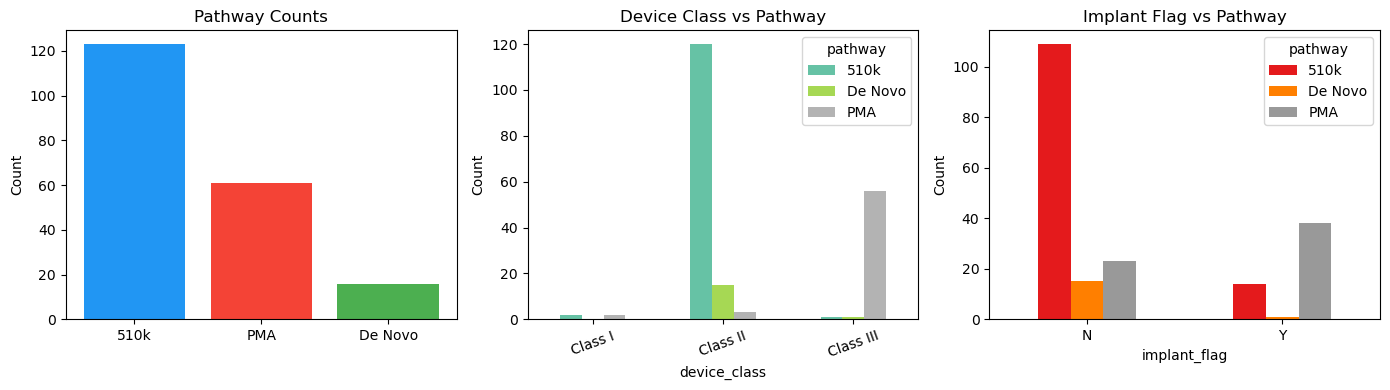

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = {'510k': '#2196F3', 'PMA': '#F44336', 'De Novo': '#4CAF50'}

# Pathway counts
counts = df_clean['pathway'].value_counts()
axes[0].bar(counts.index, counts.values, color=[palette[p] for p in counts.index])
axes[0].set_title('Pathway Counts')
axes[0].set_ylabel('Count')

# Device class by pathway
ct = pd.crosstab(df_clean['device_class'], df_clean['pathway'])
ct.plot(kind='bar', ax=axes[1], colormap='Set2', legend=True, rot=20)
axes[1].set_title('Device Class vs Pathway')
axes[1].set_ylabel('Count')

# Implant flag by pathway
ct2 = pd.crosstab(df_clean['implant_flag'], df_clean['pathway'])
ct2.plot(kind='bar', ax=axes[2], colormap='Set1', legend=True, rot=0)
axes[2].set_title('Implant Flag vs Pathway')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

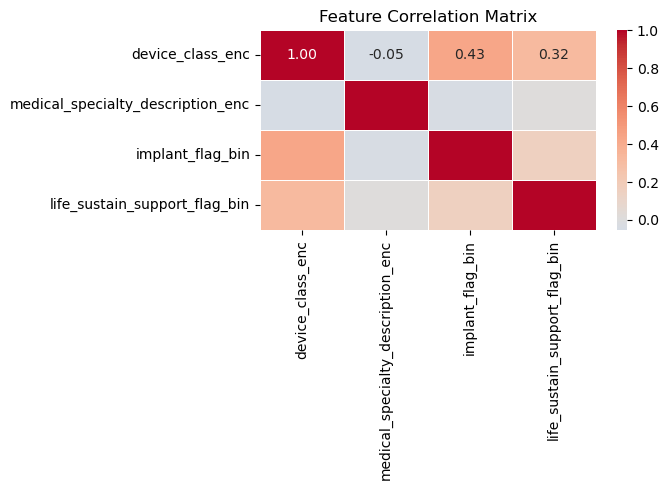

In [23]:
# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df_features[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 5. DataFrame Reference

| Variable | Contents | Rows |
|----------|----------|------|
| `df_raw` | All raw openFDA records | varies |
| `df_clean` | Cleaned + normalised | varies |
| `df_510k` | 510(k) pathway only | ~majority |
| `df_pma` | PMA pathway only | ~30% |
| `df_de_novo` | De Novo pathway only | rare |
| `df_features` | Label-encoded features + pathway | same as clean |
| `df_feat_510k` | Features — 510k only | |
| `df_feat_pma` | Features — PMA only | |
| `df_feat_de_novo` | Features — De Novo only | |
